In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/mpg.csv")

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

## What is EDA?

EDA = Exploratory Data Analysis

Think of it as:

Dataset
 ↓
Questions
 ↓
Visualizations
 ↓
Insights

### Plot 1: MPG Distribution

This answers:

Are most cars fuel efficient or not?

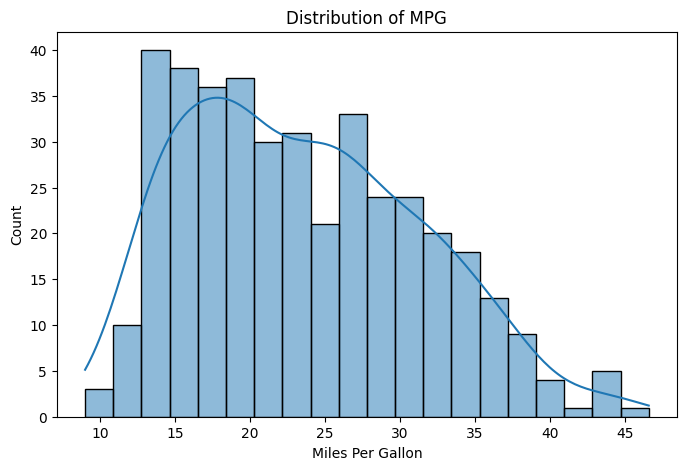

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["mpg"], bins=20, kde=True)

plt.title("Distribution of MPG")
plt.xlabel("Miles Per Gallon")
plt.ylabel("Count")

plt.show()

### Plot 2: Horsepower Distribution

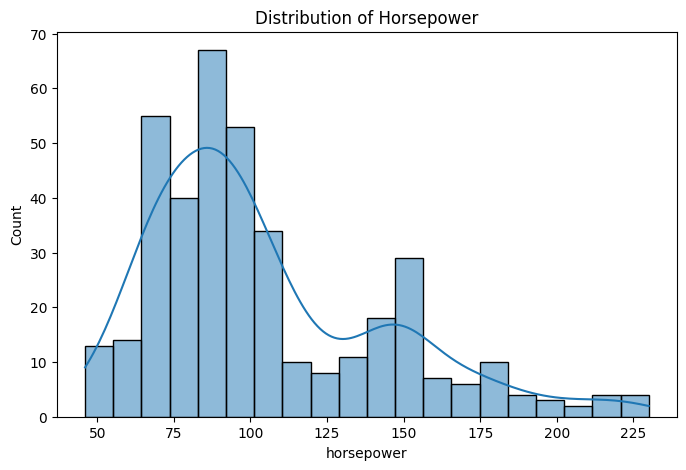

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["horsepower"], bins=20, kde=True)

plt.title("Distribution of Horsepower")

plt.show()

### Plot 3: Weight Distribution

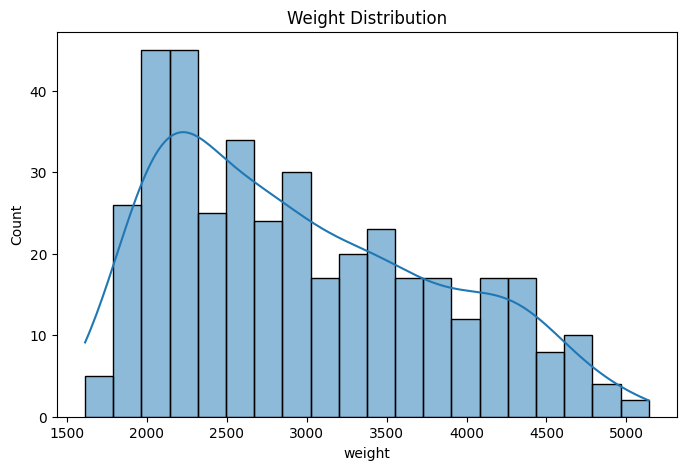

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["weight"], bins=20, kde=True)
plt.title("Weight Distribution")

plt.show()

### Plot 4: Weight vs MPG

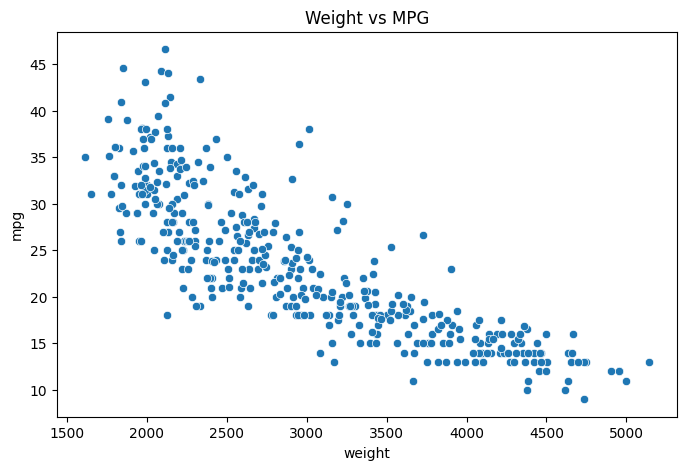

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg"
)

plt.title("Weight vs MPG")

plt.show()

### Plot 5: Horsepower vs MPG

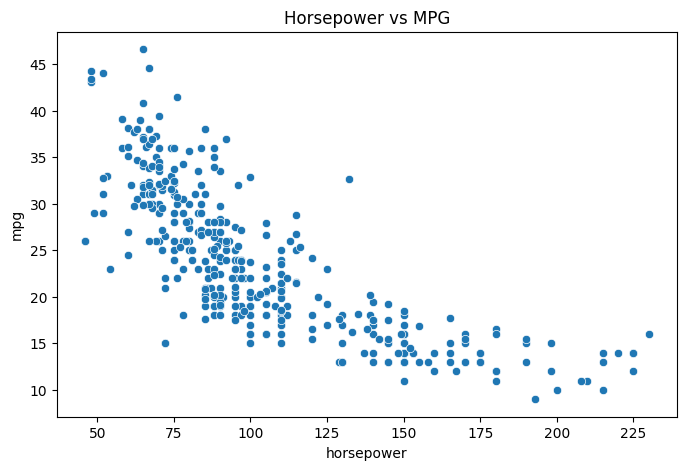

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="horsepower",
    y="mpg"
)

plt.title("Horsepower vs MPG")

plt.show()

### Plot 6: Model Year vs MPG

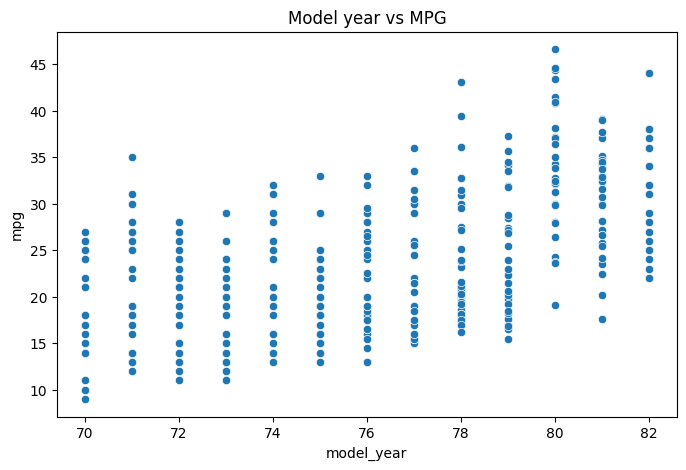

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="model_year",
    y="mpg"
)

plt.title("Model year vs MPG")

plt.show()

# Correlation Analysis

In [19]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


.select_dtypes() - A pandas method that selects columns based on their data type

include=["number"] - Specifies to include columns with numeric data types (int64, float64, etc.)

numeric_df - A new DataFrame containing only the numeric columns

## Correlation Matrix

In [20]:
corr_matrix = numeric_df.corr()
corr_matrix

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


.corr() - Pandas method that computes pairwise correlation between columns

Default method: Pearson correlation coefficient (ranges from -1 to +1)

Returns: A square matrix showing correlation between every pair of numeric columns

Understanding the correlation matrix:
Correlation value	Meaning
+1.0	 Perfect positive correlation (as one increases, the other increases proportionally)
0 to +1	 Positive correlation (tend to increase together)
0	     No linear relationship
-1 to 0	 Negative correlation (one increases as the other decreases)
-1.0	 Perfect negative correlation

## Heatmap

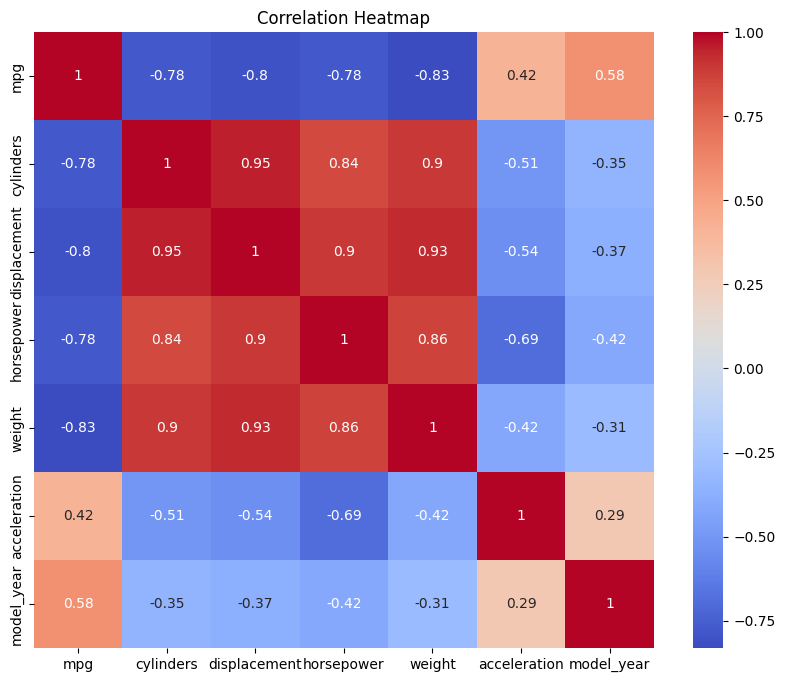

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Bonus Plot: Origin vs MPG

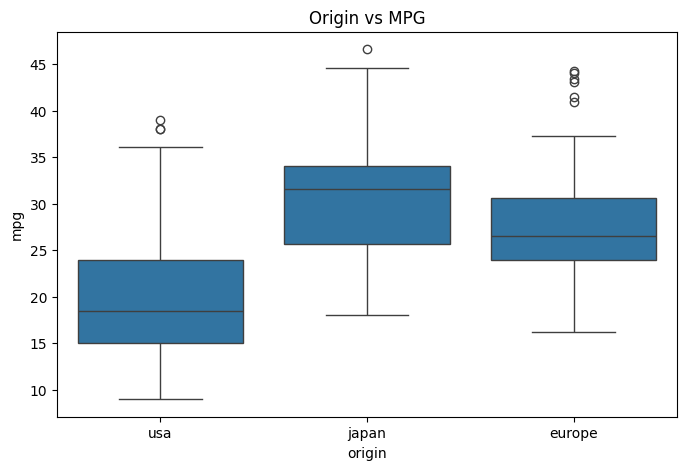

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="origin",
    y="mpg"
)

plt.title("Origin vs MPG")

plt.show()